In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
import warnings

warnings.simplefilter('ignore')

In this area, we will cover the following recipes:
* Preparing time series data for supervised learning
* One-step forecasting using linear regression models with scikit-learn
* Multi-step forecasting using linear regression models with scikit-learn
* Forecasting using non-linear models with sktime
* Optimizing a forecasting model with hyperparameter tuning
* Forecasting with exogenous variables and ensemble learning

In [2]:
path = Path('../../../Code in Zip/Time-Series-Analysis-with-Python-Cookbook-main/datasets/Ch12')

daily_temp = pd.read_csv(path.joinpath('daily_weather.csv'), index_col='DateTime', parse_dates=True)
daily_temp.columns = ['y']

energy = pd.read_csv(path.joinpath('energy_consumption.csv'), index_col='Month', parse_dates=True)
energy.columns = ['y']

air = pd.read_csv(path.joinpath('air_passenger.csv'), index_col='date', parse_dates=True)
air.columns = ['y']

In [3]:
# Then, add the proper frequency for each DataFrame
daily_temp.index.freq = 'D'
energy.index.freq = 'MS'
air.index.freq = 'M'

<Axes: title={'center': 'Monthly Passengers'}, xlabel='date'>

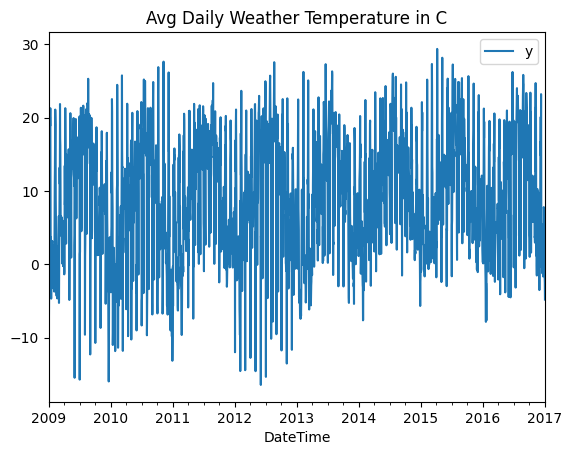

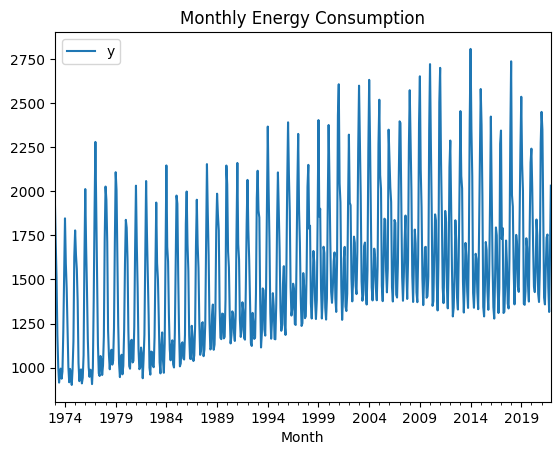

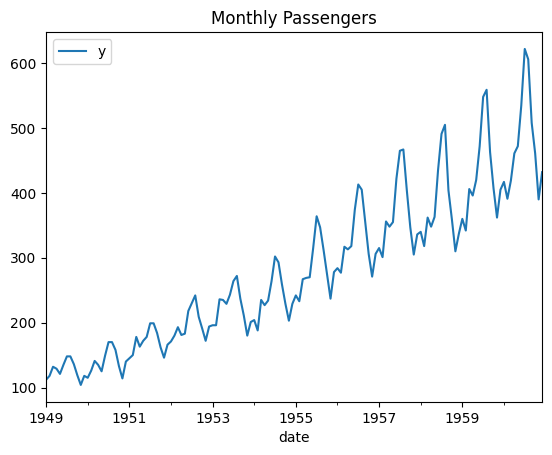

In [4]:
# You can plot the three DataFrames to gain an understanding of how they differ
daily_temp.plot(title='Avg Daily Weather Temperature in C')
energy.plot(title='Monthly Energy Consumption')
air.plot(title='Monthly Passengers')

In [5]:
air_copy = air.copy()
energy_copy = energy.copy()
daily_temp_copy = daily_temp.copy()

In [6]:
def handle_missing_data(df):
    n = int(df.isna().sum())
    if n > 0:
        print(f'found {n} missing observations...')
        df.ffill(inplace=True)

In [7]:
# Pass each DataFrame to the handle_missing_data function
for df in [air_copy, energy_copy, daily_temp_copy]:
    handle_missing_data(df)

found 2 missing observations...


Create the one_step_forecast function, which returns a DataFrame with a specified number of independent variables (columns) and a target variable (column). The total number of columns returned is based on the sliding window parameter (number of columns = sliding window + 1).

In [8]:
def one_step_forecast(df, window):
    d = df.values
    x = []
    n = len(df)
    idx = df.index[:-window]

    for start in range(n-window):
        end = start + window
        x.append(d[start:end])

    cols = [f'x_{i}' for i in range(1, window+1)]
    x = np.array(x).reshape(n-window, -1)
    y = df.iloc[window:].values
    
    df_xs = pd.DataFrame(x, columns=cols, index=idx)
    df_y = pd.DataFrame(y.reshape(-1), columns=['y'], index=idx)

    return pd.concat([df_y, df_xs], axis=1).dropna()

In [9]:
air_os = one_step_forecast(air_copy, 5)
energy_os = one_step_forecast(energy_copy, 5)
daily_temp_os = one_step_forecast(daily_temp_copy, 5)

In [10]:
def split_data(df, test_split=0.15):
    n = int(len(df) * test_split)
    train, test = df[:-n], df[-n:]
    return train, test

In [11]:
train, test = split_data(air_os)
print(f'Train: {len(train)} Test: {len(test)}')

Train: 119 Test: 20


In [ ]:
class Standardize:
    def __init__(self, split=0.15):
        self.split = split

    def _transform(self, df):
        return (df - self.mu)/self.sigma
    
    def split_data(self, df):
        n = int(len(df) * test_split)
        train, test = df[:-n], df[-n:]

        return train, test
    
    def fit_transform(self, train, test):
        self.mu = train.mean()
        self.sigma = train.std()
        train_s = self._transform(train)
        test_s = self._transform(test)

        return train_s, test_s
    
    def transform(self, df):
        return self._transform(df)
    
    def inverse(self, df):
        return (df * self.sigma)+self.mu
    
    def inverse_y(self, df):
        return (df * self.sigma[0])+self.mu[0]

In [ ]:
scaler = Standardize()
train_s, test_s = scaler.fit_transform(train, test)
train_original = scaler.inverse(train_s)
y_train_original = scaler.inverse_y(train_s['y'])

In [ ]:
# The following is an example of engineering date time related features using pandas
df['day_of_week'] = df.index.dayofweek
df['days_in_month'] = df.index.days_in_month
df['month_end'] = df.index.is_month_end.astype(int)
df['is_leap'] = df.index.is_leap_year.astype(int)
df['month'] = df.index.month
df.head()